In [2]:
#import libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
#load Dataset
df = pd.read_csv('/content/ToyotaCorolla - MLR.csv')

In [5]:
#EDA
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [28]:
df.tail()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Gears,Weight
1431,7500,69,20544,Petrol,86,0,1300,3,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,5,1015
1435,6950,76,1,Petrol,110,0,1600,5,5,1114


In [29]:
df.isna()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Gears,Weight
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
1431,False,False,False,False,False,False,False,False,False,False
1432,False,False,False,False,False,False,False,False,False,False
1433,False,False,False,False,False,False,False,False,False,False
1434,False,False,False,False,False,False,False,False,False,False


In [30]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Gears,0
Weight,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Gears      1436 non-null   int64 
 9   Weight     1436 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 112.3+ KB


In [32]:
df.shape

(1436, 10)

In [8]:
print("Dataset Summary Statistics:")
print(df.describe())

Dataset Summary Statistics:
              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

                cc        Doors  Cylinders        Gears      Weight  
count   1436.00000  1436.000000     1436.0  1436.000000  1436.00000  
mean    1576.85585     4.033426        4.0     5.026462  1072.45961  
std      424.38677     0.952677        0.0     0.188510    52.64112 

In [9]:
print("\nUnique values in Cylinders:", df['Cylinders'].unique())
df = df.drop(columns=['Cylinders'])


Unique values in Cylinders: [4]


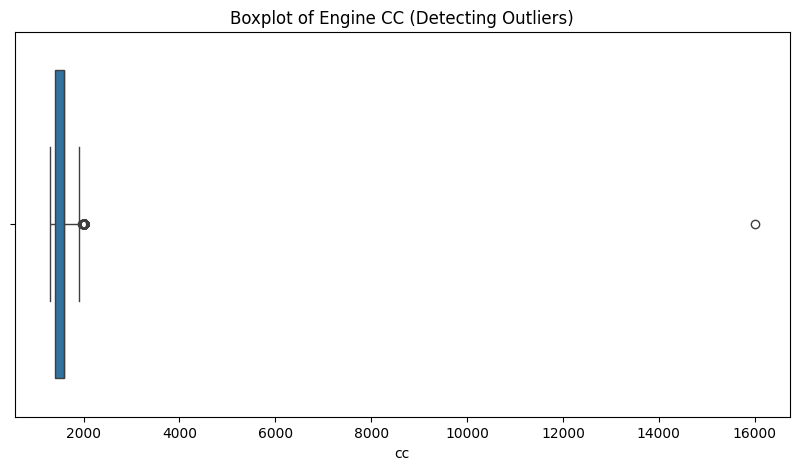

In [10]:
# Check for outliers in 'cc'
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['cc'])
plt.title('Boxplot of Engine CC (Detecting Outliers)')
plt.show()

In [11]:
# Correcting the 'cc' outlier (16000 is likely a typo for 1600)
df.loc[df['cc'] == 16000, 'cc'] = 1600

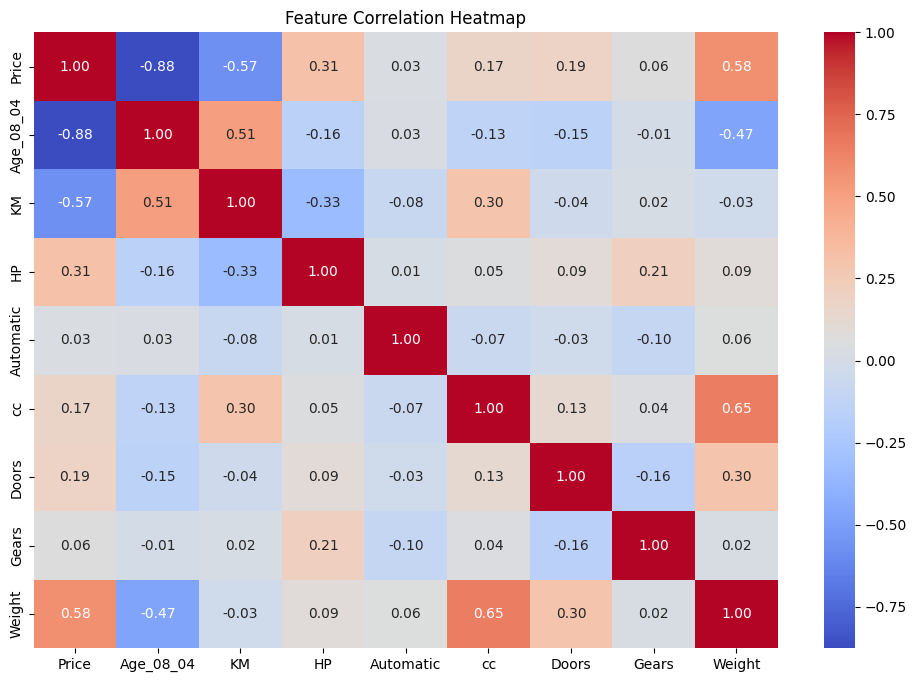

In [12]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [13]:
# Pre-processing: One-Hot Encoding for Fuel_Type
df_processed = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

In [14]:
#split the dataset
from sklearn.model_selection import train_test_split
X = df_processed.drop('Price', axis=1)
y = df_processed['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
#Model Building and Evaluation
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(model, X_tst, y_tst, name):
    preds = model.predict(X_tst)
    rmse = np.sqrt(mean_squared_error(y_tst, preds))
    r2 = r2_score(y_tst, preds)
    print(f"\nModel: {name}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.4f}")
    return r2

In [21]:
# Model 1: All features (Base Model)
model1 = LinearRegression()
model1.fit(X_train, y_train)
evaluate_model(model1, X_test, y_test, "Linear Regression (All Features)")

# Model 2: Selected High-Correlation Features
features2 = ['Age_08_04', 'KM', 'HP', 'Weight']
model2 = LinearRegression()
model2.fit(X_train[features2], y_train)
evaluate_model(model2, X_test[features2], y_test, "Linear Regression (Key Features Only)")

# Model 3: Standardized Features (All)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = LinearRegression()
model3.fit(X_train_scaled, y_train)
evaluate_model(model3, X_test_scaled, y_test, "Linear Regression (Standardized All Features)")


Model: Linear Regression (All Features)
RMSE: 1428.44
R2 Score: 0.8471

Model: Linear Regression (Key Features Only)
RMSE: 1411.85
R2 Score: 0.8506

Model: Linear Regression (Standardized All Features)
RMSE: 1428.44
R2 Score: 0.8471


0.8470757900790585

In [22]:
# Interpreting Coefficients (Model 1)
coeffs = pd.DataFrame({'Feature': X.columns, 'Coefficient': model1.coef_})
print("\nCoefficient Interpretation (Model 1):")
print(coeffs.sort_values(by='Coefficient', ascending=False))


Coefficient Interpretation (Model 1):
            Feature  Coefficient
8  Fuel_Type_Diesel  2035.927064
9  Fuel_Type_Petrol  1289.973942
6             Gears   478.134018
3         Automatic   207.770928
2                HP    41.561829
7            Weight    25.005582
1                KM    -0.015451
4                cc    -3.136174
5             Doors   -25.626048
0         Age_08_04  -119.787684


In [23]:
#Lasso and Ridge Regression
lasso = Lasso(alpha=1.0)
lasso.fit(X_train_scaled, y_train)
evaluate_model(lasso, X_test_scaled, y_test, "Lasso Regression")

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
evaluate_model(ridge, X_test_scaled, y_test, "Ridge Regression")


Model: Lasso Regression
RMSE: 1430.62
R2 Score: 0.8466

Model: Ridge Regression
RMSE: 1429.23
R2 Score: 0.8469


0.846906063295522

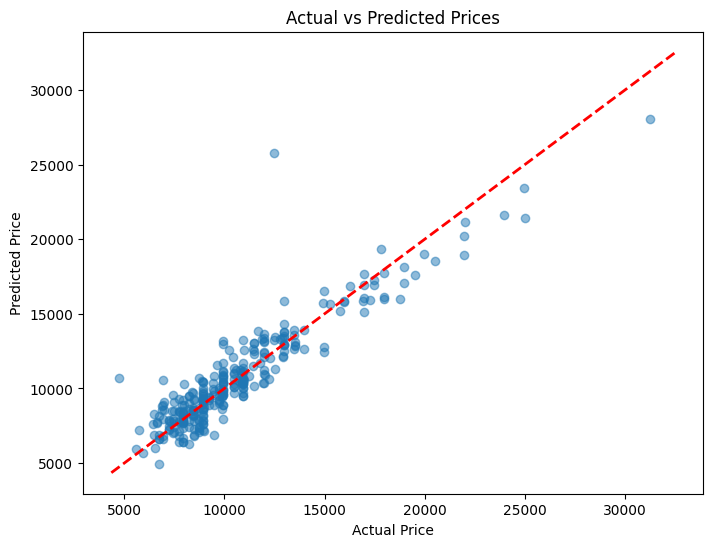

In [27]:
# Visualizing Predicted vs Actual Prices (for Model 1)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, model1.predict(X_test), alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()

# Interview Questions

### 1. What is Normalization & Standardization and how is it helpful?

**Normalization (Min-Max Scaling):**
* **Definition:** It scales the data to a fixed range, usually between 0 and 1.
* **Formula:** $X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$
* **When to use:** It is useful when the distribution of data does not follow a Gaussian (Normal) distribution and is particularly helpful for algorithms that do not assume any distribution (e.g., K-Nearest Neighbors, Neural Networks).

**Standardization (Z-score Normalization):**
* **Definition:** It scales the data so that it has a mean ($\mu$) of 0 and a standard deviation ($\sigma$) of 1.
* **Formula:** $z = \frac{X - \mu}{\sigma}$
* **When to use:** It is preferred when the data follows a Gaussian distribution or when using algorithms that assume centered data (e.g., Linear Regression, Logistic Regression, SVM).

**How they are helpful:**
* **Prevents Dominance:** Features with very large scales (like `KM` in our dataset) won't dominate features with smaller scales (like `Doors`).
* **Faster Convergence:** Optimization algorithms like Gradient Descent converge much faster when features are on a similar scale.
* **Improved Accuracy:** Distance-based algorithms (like KNN or Clustering) rely on the magnitude of features; scaling ensures all features contribute equally to the distance calculation.

---

### 2. What techniques can be used to address multicollinearity in multiple linear regression?

Multicollinearity occurs when independent variables are highly correlated with each other, making it difficult for the model to estimate the individual effect of each variable on the target.

**Techniques to address it:**

1. **VIF (Variance Inflation Factor):**
   * Calculate the VIF for each independent variable.
   * **Rule of Thumb:** A VIF value $> 5$ or $10$ indicates high multicollinearity. Variables with high VIF should be considered for removal.

2. **Feature Selection (Manual Removal):**
   * Identify pairs of variables with high correlation (using a correlation heatmap).
   * Remove one of the variables from the pair that is logically redundant or has less predictive power.

3. **Principal Component Analysis (PCA):**
   * Transform the original correlated variables into a new set of linearly uncorrelated variables called "Principal Components."

4. **Regularization (Ridge and Lasso Regression):**
   * **Ridge Regression ($L_2$):** Shrinks the coefficients of correlated predictors towards each other, reducing their impact.
   * **Lasso Regression ($L_1$):** Can shrink the coefficients of less important, highly correlated variables all the way to zero, effectively performing feature selection.

5. **Increasing Sample Size:**
   * Sometimes, multicollinearity is a result of a small or biased sample. Adding more data can occasionally help resolve the instability in coefficient estimates.